# Rob Mulla Channel - Image Processing with OpenCV and Python

In [6]:
import pandas as pd
import numpy as np

from glob import glob

import cv2
import matplotlib.pylab as plt

In [8]:
cat_files = glob('../datasets/cat_vs_dog/training_set/cats/*.jpg')
dog_files = glob('../datasets/cat_vs_dog/training_set/dogs/*.jpg')

In [10]:
img_mpl = plt.imread(cat_files[20])
img_cv2 = cv2.imread(cat_files[20])

In [12]:
img_mpl.shape, img_cv2.shape

((287, 288, 3), (287, 288, 3))

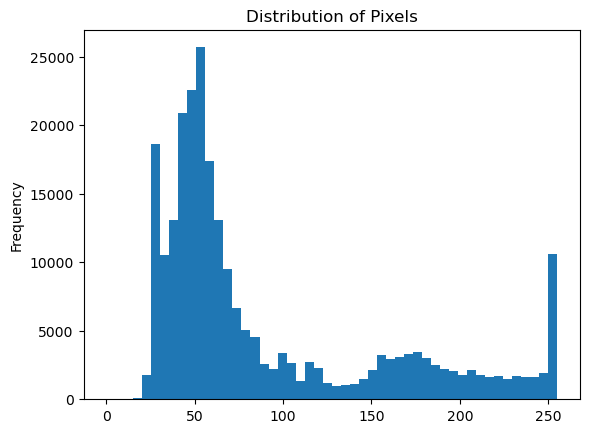

In [14]:
pd.Series(img_mpl.flatten()).plot(kind='hist', bins=50, title = 'Distribution of Pixels')
plt.show()

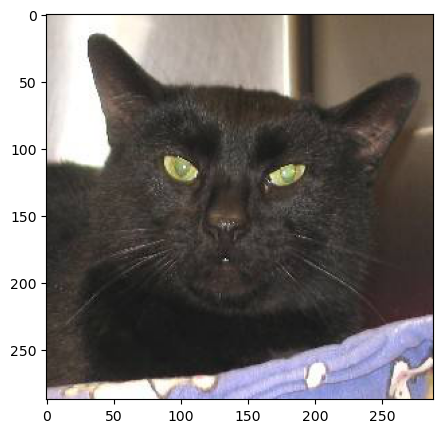

In [20]:
fig, ax= plt.subplots(figsize=(5,5))
# ax.axis('off')
ax.imshow(img_mpl)
plt.show()

Text(0.5, 1.0, 'Red Channel')

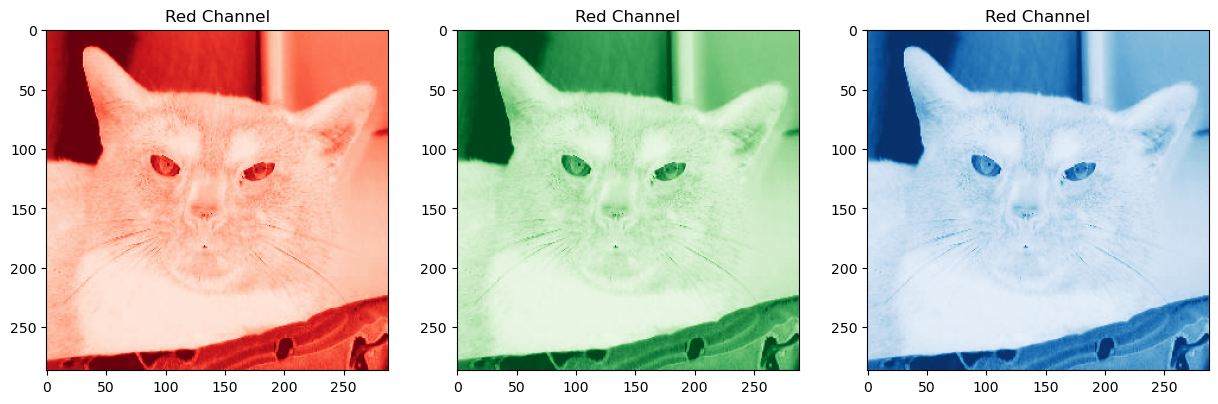

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img_mpl[:,:,0], cmap ='Reds')
axs[1].imshow(img_mpl[:,:,0], cmap ='Greens')
axs[2].imshow(img_mpl[:,:,0], cmap ='Blues')
axs[0].set_title('Red Channel')
axs[1].set_title('Red Channel')
axs[2].set_title('Red Channel')

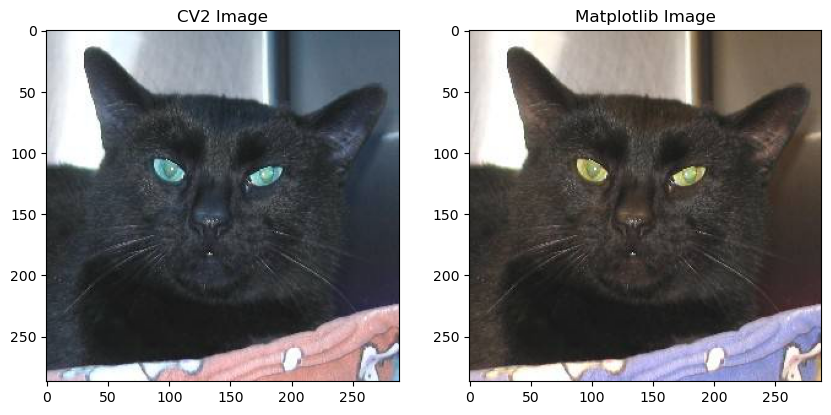

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_cv2)
axs[1].imshow(img_mpl)
axs[0].set_title('CV2 Image')
axs[1].set_title('Matplotlib Image')
plt.show()

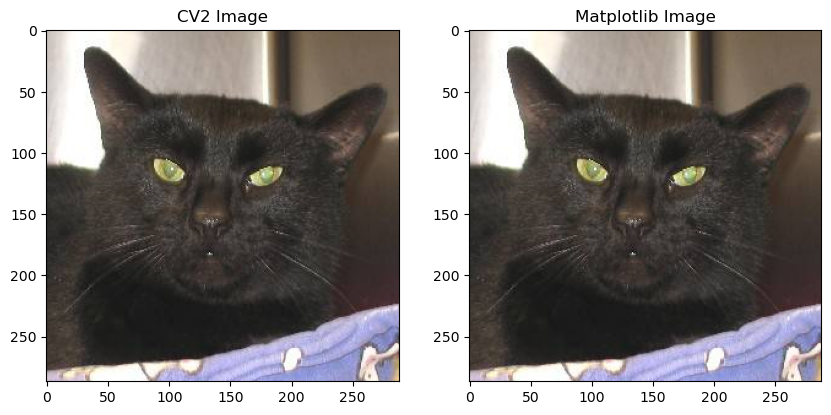

In [32]:
img_cv2_cvt = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_cv2_cvt)
axs[1].imshow(img_mpl)
axs[0].set_title('CV2 Image')
axs[1].set_title('Matplotlib Image')
plt.show()

In [36]:
img = plt.imread(dog_files[0])

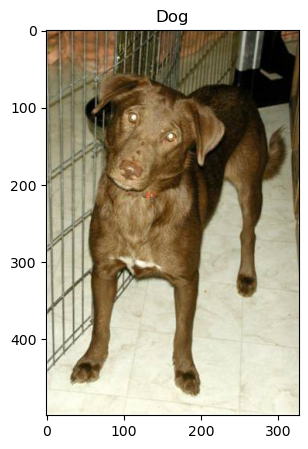

In [42]:
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img)
axs.set_title('Dog')
plt.show()

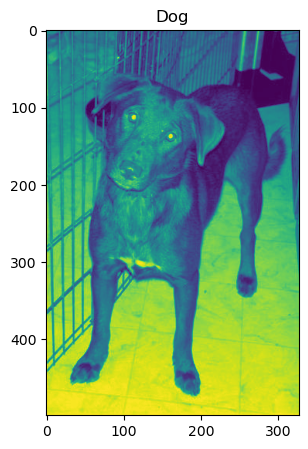

In [44]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img_gray)
axs.set_title('Dog')
plt.show()

In [48]:
img.shape, img_gray.shape

((499, 327, 3), (499, 327))

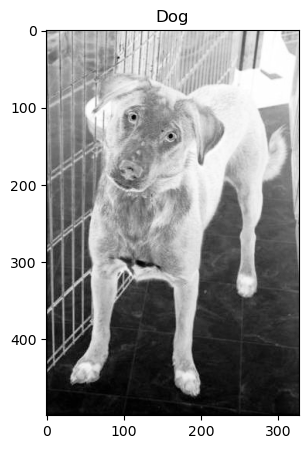

In [50]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img_gray, cmap='Greys')
axs.set_title('Dog')
plt.show()

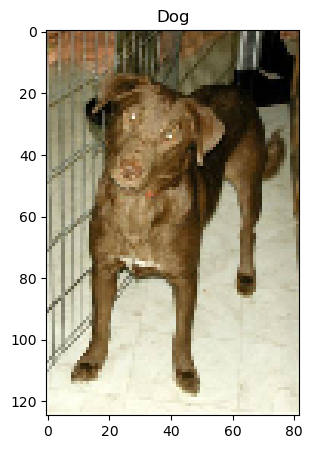

In [52]:
img_resized = cv2.resize(img, None, fx = 0.25, fy = 0.25)
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img_resized)
axs.set_title('Dog')
plt.show()

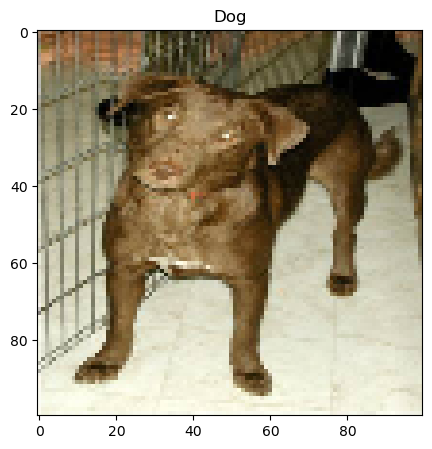

In [54]:
img_resized = cv2.resize(img, (100, 100))
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img_resized)
axs.set_title('Dog')
plt.show()

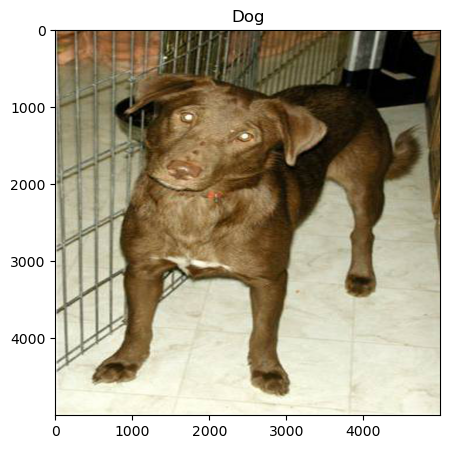

In [56]:
img_resized = cv2.resize(img, (5000, 5000), interpolation=cv2.INTER_CUBIC)
fig, axs = plt.subplots(figsize=(5, 5))
axs.imshow(img_resized)
axs.set_title('Dog')
plt.show()

In [58]:
img_resized.shape

(5000, 5000, 3)

In [ ]:
# sharpenning

In [ ]:
# blurring

# Campusx - Video 49 (Cats vs Dogs Image Classification)

In [61]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [63]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '../datasets/cat_vs_dog/training_set',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = '../datasets/cat_vs_dog/test_set',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [65]:
# normalize
def process(image, label):
    image = tf.cast(image/255, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [67]:
# create CNN model
model = Sequential()

model.add(Conv2D(32, kernel_size= (3,3), padding = 'valid', activation='relu', input_shape = (256, 256, 3)))
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size= (3,3), padding = 'valid', activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size= (3,3), padding = 'valid', activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\koyel\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [77]:
history = model.fit(train_ds, epochs=10, validation_data = validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.5358 - loss: 0.6892 - val_accuracy: 0.6471 - val_loss: 0.6326
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.6646 - loss: 0.6162 - val_accuracy: 0.7049 - val_loss: 0.5791
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7373 - loss: 0.5213 - val_accuracy: 0.7059 - val_loss: 0.5656
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.8136 - loss: 0.4109 - val_accuracy: 0.7261 - val_loss: 0.6451
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.8728 - loss: 0.2829 - val_accuracy: 0.7375 - val_loss: 0.7709
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.9348 - loss: 0.1685 - val_accuracy: 0.6876 - val_loss: 1.2399
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9668 - loss: 0.0874 - val_accuracy: 0.7103 - val_loss: 1.2670
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.9722 - loss: 0.0759 - val_accu

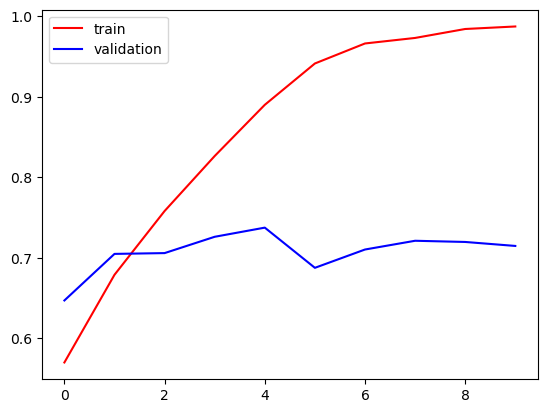

In [82]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()
# seems overfitting?

In [ ]:
# create CNN model (added dropout ratio 0f 0.2)
model1 = Sequential()

model1.add(Conv2D(32, kernel_size= (3,3), padding = 'valid', activation='relu', input_shape = (256, 256, 3)))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model1.add(Conv2D(64, kernel_size= (3,3), padding = 'valid', activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model1.add(Conv2D(128, kernel_size= (3,3), padding = 'valid', activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model1.add(Flatten())

model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.1))
model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.1))
model1.add(Dense(1, activation='sigmoid'))

In [ ]:
model1.summary()

In [ ]:
model1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
history1 = model1.fit(train_ds, epochs=10, validation_data = validation_ds)

In [ ]:
plt.plot(history1.history['accuracy'], color='red', label='train')
plt.plot(history1.history['val_accuracy'], color='red', label='validation')
plt.legend()
plt.show()

# CampusX - Data Augmentation - Video - 50

In [79]:
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (C:\Users\koyel\anaconda3\Lib\site-packages\keras\api\preprocessing\image\__init__.py)

In [ ]:
# load one image
img = image.load_img('../datasets/cat_vs_dog/training_set/cats/cat.998.jpg', target_size = (200, 200))

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.imshow(img)

In [ ]:
type(img) # this is not opencv, so can't treat as numpy array, if we will use opencv, then image stored as numpy array, we can apply numpy operations on that

In [ ]:
datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2, 
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    fill_mode = 'nearest' # 'constant', 'reflect'
)

In [ ]:
img.shape

In [ ]:
img = image.img_to_array(img)

In [ ]:
img.shape

In [ ]:
input_batch = img.reshape(1,200,200,3)

In [ ]:
i = 0
for output in datagen.flow(input_batch, batch_size=1, save_to_dir = 'aug_img'):
    i = i+1
    if i == 10:
        break

In [ ]:
input_batch.shape

# Pre Trained Model

In [89]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [91]:
model = ResNet50('imagenet')

 41148416/102967424 ━━━━━━━━━━━━━━━━━━━━ 34:36 34us/step

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels.h5: None -- retrieval incomplete: got only 41143126 out of 102967424 bytes

In [93]:
img_path = '../datasets/cat_vs_dog/training_set/cats/cat.998.jpg'
img = image.load_image(img_path, target_size = (224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

AttributeError: module 'keras._tf_keras.keras.preprocessing.image' has no attribute 'load_image'

In [ ]:
preds = model.predict(x)
print('Predicted: ', decode_predictions(preds, top=3)[0])